In [ ]:
df.to_excel('Dataset_With_Features.xlsx', index=False)
from google.colab import files
files.download('Dataset_With_Features.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

features = df[['perplexity', 'burstiness', 'lexical_density']].fillna(0)
labels = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('=== SVM RESULTS ===')
print('Accuracy:', round(accuracy_score(y_test, svm_pred)*100, 1), '%')
print('Precision:', round(precision_score(y_test, svm_pred)*100, 1), '%')
print('Recall:', round(recall_score(y_test, svm_pred)*100, 1), '%')

print()
print('=== RANDOM FOREST RESULTS ===')
print('Accuracy:', round(accuracy_score(y_test, rf_pred)*100, 1), '%')
print('Precision:', round(precision_score(y_test, rf_pred)*100, 1), '%')
print('Recall:', round(recall_score(y_test, rf_pred)*100, 1), '%')

=== SVM RESULTS ===
Accuracy: 68.8 %
Precision: 56.5 %
Recall: 92.9 %

=== RANDOM FOREST RESULTS ===
Accuracy: 73.0 %
Precision: 62.5 %
Recall: 80.4 %


In [ ]:
from google.colab import files
files.download('feature_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_17235/2838081314.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='perplexity', ax=axes[0], palette='Set2')
/tmp/ipykernel_17235/2838081314.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='burstiness', ax=axes[1], palette='Set2')
/tmp/ipykernel_17235/2838081314.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='lexical_density', ax=axes[2], palette='Set2')


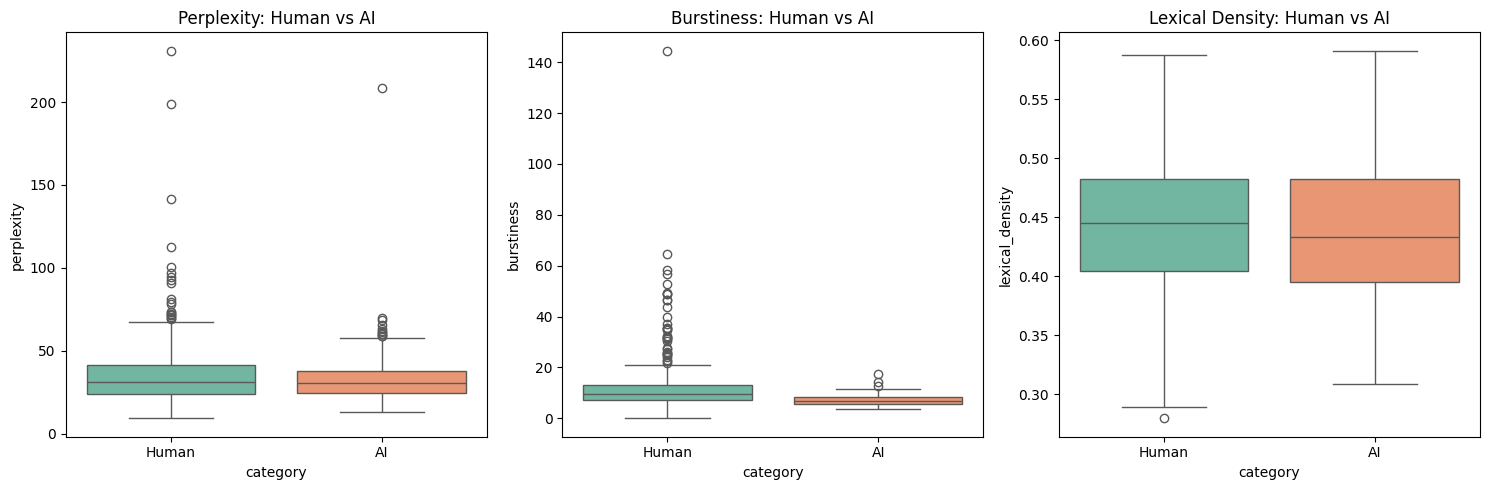

Chart saved successfully


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df['category'] = df['label'].map({0: 'Human', 1: 'AI'})

sns.boxplot(data=df, x='category', y='perplexity', ax=axes[0], palette='Set2')
axes[0].set_title('Perplexity: Human vs AI')

sns.boxplot(data=df, x='category', y='burstiness', ax=axes[1], palette='Set2')
axes[1].set_title('Burstiness: Human vs AI')

sns.boxplot(data=df, x='category', y='lexical_density', ax=axes[2], palette='Set2')
axes[2].set_title('Lexical Density: Human vs AI')

plt.tight_layout()
plt.savefig('feature_comparison.png', dpi=150)
plt.show()
print('Chart saved successfully')

In [ ]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import torch

tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()

def calculate_perplexity(text):
    if pd.isna(text) or len(str(text)) < 10:
        return 0
    try:
        inputs = tokenizer(str(text)[:1024], return_tensors='pt', truncation=True)
        with torch.no_grad():
            outputs = model(**inputs, labels=inputs['input_ids'])
        return torch.exp(outputs.loss).item()
    except:
        return 0

df['perplexity'] = df['content'].apply(calculate_perplexity)
print('Perplexity calculated successfully')
print(df.groupby('label')['perplexity'].mean())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Perplexity calculated successfully
label
0    36.129513
1    32.223422
Name: perplexity, dtype: float64


In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm')

def calculate_lexical_density(text):
    if pd.isna(text) or len(str(text)) < 10:
        return 0
    doc = nlp(str(text)[:10000])
    content_pos = {'NOUN', 'VERB', 'ADJ', 'ADV'}
    total = len([t for t in doc if not t.is_space])
    content = len([t for t in doc if t.pos_ in content_pos])
    if total == 0:
        return 0
    return content / total

df['lexical_density'] = df['content'].apply(calculate_lexical_density)
print('Lexical density calculated successfully')
print(df.groupby('label')['lexical_density'].mean())

Lexical density calculated successfully
label
0    0.441790
1    0.439545
Name: lexical_density, dtype: float64


In [ ]:
import nltk
import numpy as np
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

def calculate_burstiness(text):
    if pd.isna(text) or len(str(text)) < 10:
        return 0
    sentences = sent_tokenize(str(text))
    if len(sentences) < 2:
        return 0
    lengths = [len(s.split()) for s in sentences]
    return np.std(lengths)

df['burstiness'] = df['content'].apply(calculate_burstiness)
print('Burstiness calculated successfully')
print(df.groupby('label')['burstiness'].mean())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Burstiness calculated successfully
label
0    12.541669
1     7.010341
Name: burstiness, dtype: float64


In [ ]:
import pandas as pd
df = pd.read_excel('Master_Dataset_700.xlsx', sheet_name='Combined_For_Analysis')
print('Total samples:', len(df))
print('Human texts:', len(df[df['label']==0]))
print('AI texts:', len(df[df['label']==1]))

Total samples: 704
Human texts: 354
AI texts: 350


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Master_Dataset_700.xlsx to Master_Dataset_700.xlsx


In [ ]:
!pip install nltk spacy pandas openpyxl matplotlib seaborn scikit-learn transformers torch
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 72.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
